In [1]:
clc;
clear;
close all;

Fs = 100000;
t = 0:1/Fs:0.02;
fc = 1000;

% Message signals
m1 = cos(2*pi*100*t);    % Message 1
m2 = sin(2*pi*200*t);    % Message 2


## VSB Modulation

In [2]:
% DSB-SC modulation
dsb = m1 .* cos(2*pi*fc*t);

% Design a filter to create VSB (low-pass + partial sideband)
[b,a] = butter(6, (fc+200)/(Fs/2), 'low');
vsb = filter(b,a,dsb);


## ISB Modulation


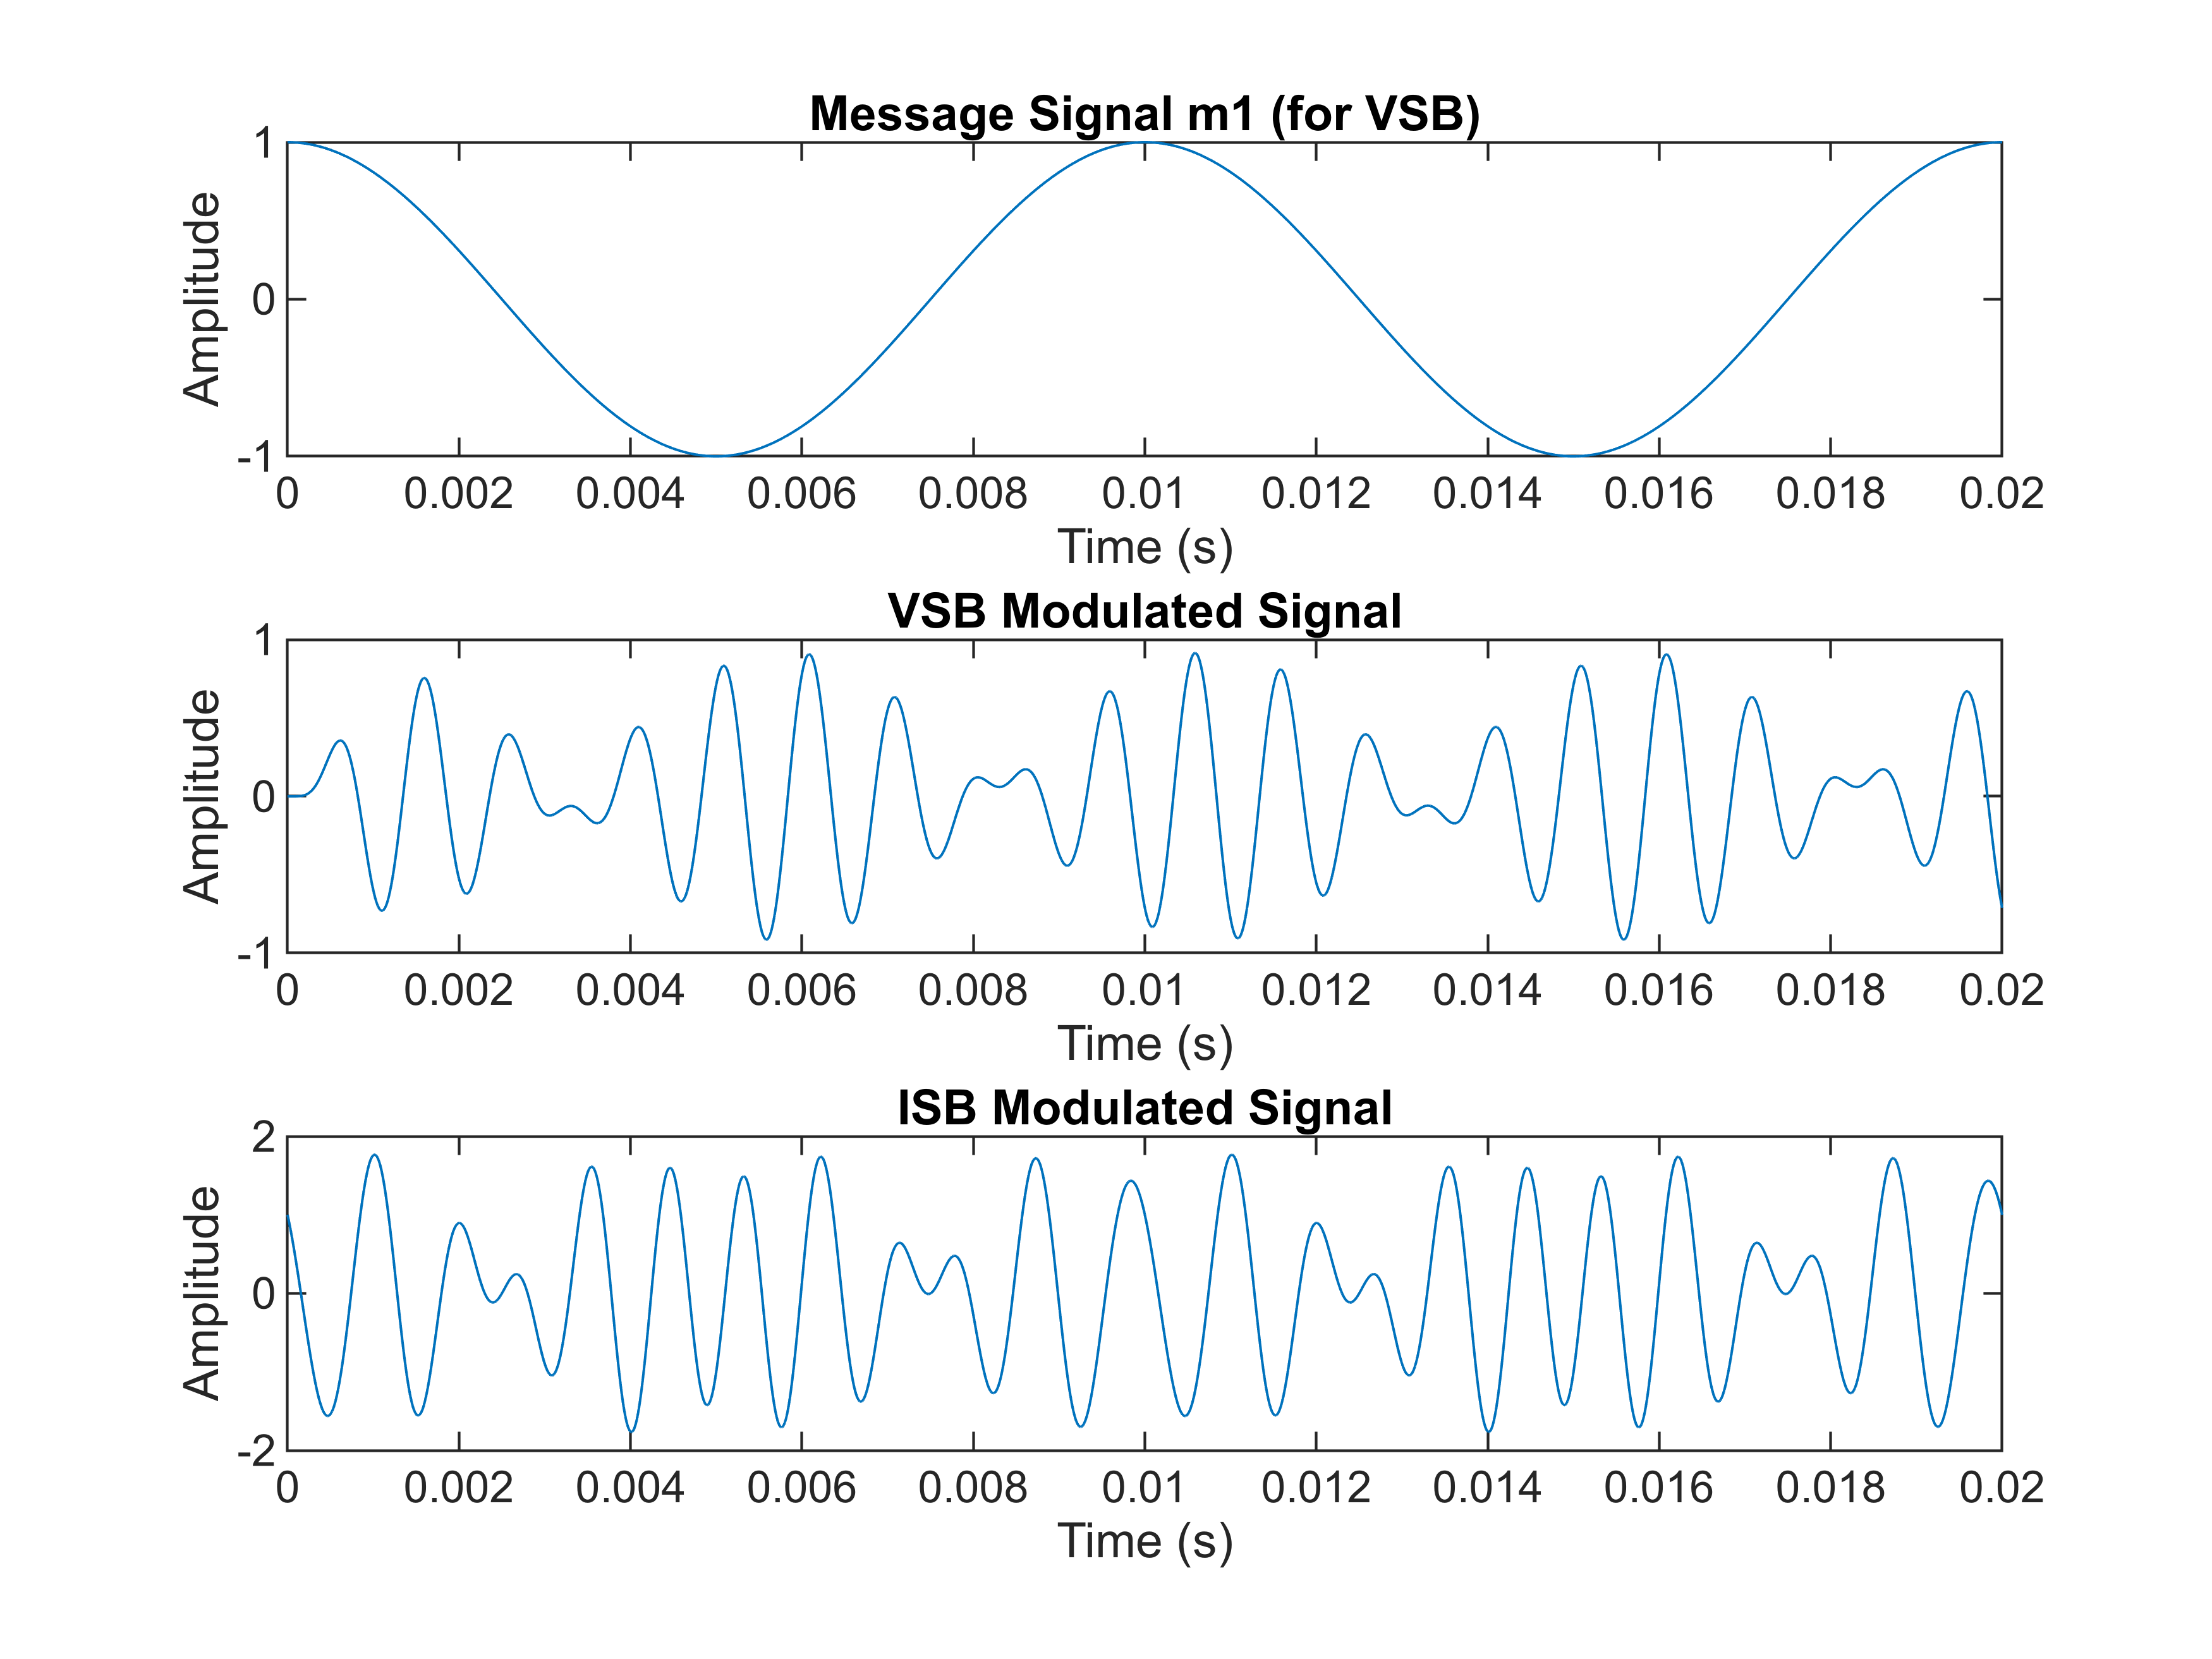

In [3]:
% Upper sideband carries m1, lower sideband carries m2
usb = m1 .* cos(2*pi*fc*t) - hilbert(m1).*sin(2*pi*fc*t);
lsb = m2 .* cos(2*pi*fc*t) + hilbert(m2).*sin(2*pi*fc*t);
isb = real(usb) + real(lsb);

subplot(3,1,1);
plot(t,m1); title('Message Signal m1 (for VSB)');
xlabel('Time (s)'); ylabel('Amplitude');

subplot(3,1,2);
plot(t,vsb); title('VSB Modulated Signal');
xlabel('Time (s)'); ylabel('Amplitude');

subplot(3,1,3);
plot(t,isb); title('ISB Modulated Signal');
xlabel('Time (s)'); ylabel('Amplitude');



!!!EndOutputRegion!!!